# Phase 3 — Size Recommender
**ADSP 31017 Machine Learning I — Winter 2026**  
**Authors:** Harleen Kaur Buttar, Skylar Liu, Dora Jiayue Li

Builds a collaborative-filtering size recommender on top of the fit probabilities saved in Phase 2.

**Pipeline:**
1. Load per-model fit probability CSVs → soft ensemble P(Fit)
2. Merge ensemble probabilities onto RentTheRunway transaction data
3. Build sparse user × (item_id, size) matrix valued by P(Fit)
4. Cosine-similarity collaborative filtering → recommend size per user–item pair
5. Evaluate hit-rate (warm-start) and cold-start via nearest-measurement neighbour
6. Cross-retailer generalisation: train on ModCloth, evaluate on RentTheRunway

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = Path("../../Data/Processed")
FIGURES_DIR = Path("../../Figures/Recommender_Outputs")
MODEL_DIR = Path("../../Data/Processed/Supervised_Outputs")
FIGURES_DIR.mkdir(exist_ok=True)

MODEL_NAMES = [
    "linear_svm",
    "kernel_svm",
    "cart",
    "random_forest",
    "bagging",
    "knn",
    "naive_bayes",
]

PROBA_COLS = ["prob_small","prob_fit","prob_large"]

## 1. Load Per-Model Probabilities → Soft Ensemble

In [27]:
def load_ensemble_proba(model_names):

    weighted_sum = None
    total_weight = 0
    true_labels = None

    for name in model_names:

        path = MODEL_DIR / f"{name}_fit_probabilities.csv"

        if not path.exists():
            print(f"[WARN] {path.name} missing")
            continue

        df = pd.read_csv(path)

        probs = df[PROBA_COLS].values

        if weighted_sum is None:
            weighted_sum = probs
            true_labels = df["true_fit"]
        else:
            weighted_sum += probs

        total_weight += 1

        print(f"Loaded {path.name}")

    ensemble = pd.DataFrame(
        weighted_sum / total_weight,
        columns=PROBA_COLS
    )

    ensemble["pred_label"] = (
        ensemble[PROBA_COLS]
        .idxmax(axis=1)
        .str.replace("prob_","")
    )

    ensemble["true_label"] = true_labels.values

    return ensemble

In [28]:
ensemble_df = load_ensemble_proba(MODEL_NAMES)
ensemble_df.head()

Loaded linear_svm_fit_probabilities.csv
Loaded kernel_svm_fit_probabilities.csv
Loaded cart_fit_probabilities.csv
Loaded random_forest_fit_probabilities.csv
Loaded bagging_fit_probabilities.csv
Loaded knn_fit_probabilities.csv
Loaded naive_bayes_fit_probabilities.csv


,prob_small,prob_fit,prob_large,pred_label,true_label
0,0.027192,0.099372,0.873437,large,2
1,0.277806,0.597994,0.124200,fit,1
2,0.326075,0.548435,0.125489,fit,1
3,0.340326,0.455533,0.204141,fit,0
4,0.634240,0.325120,0.040640,small,0


### Ensemble prediction distribution

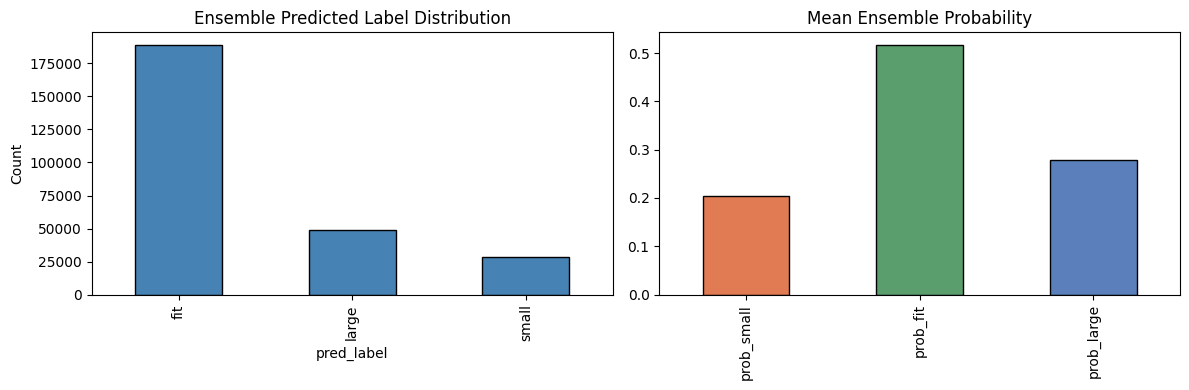

In [29]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

ensemble_df["pred_label"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="steelblue",
    edgecolor="black"
)

axes[0].set_title("Ensemble Predicted Label Distribution")
axes[0].set_ylabel("Count")

ensemble_df[PROBA_COLS].mean().plot(
    kind="bar",
    ax=axes[1],
    color=["#e07b54","#5b9e6d","#5b7fba"],
    edgecolor="black"
)

axes[1].set_title("Mean Ensemble Probability")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR/"ensemble_probability_summary.png",
    dpi=300
)

plt.show()

## 2. Load Transaction Data & Merge Ensemble Probabilities

In [30]:
def normalize_category(cat):

    cat = str(cat).lower()

    if any(x in cat for x in ["dress","gown","ballgown","caftan"]):
        return "dress"

    if any(x in cat for x in ["top","blouse","cami","shirt","buttondown","cardigan"]):
        return "top"

    if any(x in cat for x in ["blazer","jacket","coat","bomber","cape"]):
        return "outerwear"

    if any(x in cat for x in ["bottom","pant","jean","skirt"]):
        return "bottom"

    return "other"


def load_data(retailer="renttherunway", ensemble_df=None):

    path = PROCESSED_DIR / f"{retailer}_clean.csv"
    df = pd.read_csv(path)

    if ensemble_df is not None:
        df = df.join(ensemble_df[PROBA_COLS], how="left")
    else:
        df["prob_fit"] = (df["fit"]=="fit").astype(float)

    df["category"] = df["category"].apply(normalize_category)

    return df

In [31]:
df_rtr = load_data("renttherunway", ensemble_df)

print(df_rtr.shape)

df_rtr[[
"user_id",
"item_id",
"category",
"size",
"fit",
"prob_fit"
]].head()

(192544, 26)


,user_id,item_id,category,size,fit,prob_fit
0,420272,2260466,other,14,fit,0.099372
1,273551,153475,dress,12,fit,0.597994
2,360448,1063761,other,4,fit,0.548435
3,909926,126335,dress,8,fit,0.455533
4,151944,616682,dress,12,fit,0.325120


## 3. Build Sparse User–Item Matrix

In [32]:
def build_user_item_matrix(df,value_col="prob_fit"):

    df = df.dropna(subset=["user_id","category","size",value_col]).copy()

    df["item_key"] = df["category"]+"__"+df["size"].astype(str)

    user_le = LabelEncoder().fit(df["user_id"])
    item_le = LabelEncoder().fit(df["item_key"])

    rows = user_le.transform(df["user_id"])
    cols = item_le.transform(df["item_key"])

    vals = df[value_col].values

    matrix = csr_matrix(
        (vals,(rows,cols)),
        shape=(len(user_le.classes_),len(item_le.classes_))
    )

    print("Matrix shape:",matrix.shape)

    return matrix,user_le,item_le

## 4. Collaborative-Filtering Recommender

In [33]:
class SizeRecommender:

    def __init__(self, k=30, alpha=0.7, pop_weight=0.2):

        self.k = k
        self.alpha = alpha
        self.pop_weight = pop_weight

        self.matrix = None
        self.user_le = None
        self.item_le = None
        self.df_train = None
        self.size_popularity = None
        self.user_measurements = None


    def fit(self, df, value_col="prob_fit"):

        self.df_train = df.copy()

        self.matrix, self.user_le, self.item_le = build_user_item_matrix(df, value_col)

        # Size popularity prior
        self.size_popularity = (
            df.groupby(["category", "size"])
            .size()
            .rename("count")
            .reset_index()
        )

        self.size_popularity["popularity"] = (
            self.size_popularity["count"] /
            self.size_popularity.groupby("category")["count"].transform("sum")
        )

        # Body measurements table
        meas_cols = [
            c for c in [
                "height_inches",
                "weight_lbs",
                "age",
                "bust_band",
                "cup_size_num"
            ] if c in df.columns
        ]

        if meas_cols:
            self.user_measurements = (
                df.groupby("user_id")[meas_cols]
                .first()
                .dropna()
            )
        else:
            self.user_measurements = None

        return self


    def _row(self, user_id):

        if user_id not in set(self.user_le.classes_):
            return None

        idx = self.user_le.transform([user_id])[0]

        return self.matrix[idx]


    def _cold_start_row(self, measurements):

        if self.user_measurements is None:
            return None

        meas_cols = self.user_measurements.columns.tolist()

        query = np.array([measurements.get(c, np.nan) for c in meas_cols])

        valid = ~np.isnan(query)

        if valid.sum() == 0:
            return None

        train = self.user_measurements.values[:, valid]

        dists = np.linalg.norm(train - query[valid], axis=1)

        nearest_user = self.user_measurements.index[np.argmin(dists)]

        return self._row(nearest_user)


    def recommend(self, category, user_id=None, measurements=None):

        # Warm start
        if user_id is not None:
            query = self._row(user_id)

        # Cold start
        elif measurements is not None:
            query = self._cold_start_row(measurements)

        else:
            raise ValueError("Provide user_id or measurements")

        if query is None:
            return pd.DataFrame()

        item_cols = {
            k: i for i, k in enumerate(self.item_le.classes_)
            if k.startswith(category + "__")
        }

        if not item_cols:

    # fallback: recommend most popular sizes
            pop = self.size_popularity[
                self.size_popularity["category"] == category
            ]

            return pop.sort_values("popularity", ascending=False)[
                ["size", "popularity"]
            ].rename(columns={"popularity": "score"})

        sim = cosine_similarity(query, self.matrix).flatten()

        records = []

        for item_key, col_idx in item_cols.items():

            size = item_key.split("__")[1]

            col_vals = self.matrix[:, col_idx].toarray().flatten()

            interacted = np.where(col_vals > 0)[0]

            if len(interacted) == 0:
                continue

            top_k = interacted[np.argsort(sim[interacted])[::-1][:self.k]]

            weights = sim[top_k]
            probs = col_vals[top_k]

            weighted_prob = np.sum(weights * probs) / (np.sum(weights) + 1e-6)

            # Popularity prior
            pop_row = self.size_popularity[
                (self.size_popularity["category"] == category) &
                (self.size_popularity["size"].astype(str) == size)
            ]

            pop = pop_row["popularity"].values[0] if len(pop_row) > 0 else 0

            score = (
                self.alpha * weighted_prob +
                self.pop_weight * pop
            )

            score = np.clip(score, 0, 1)

            records.append({
                "size": size,
                "score": round(score, 4),
                "weighted_prob": round(weighted_prob, 4),
                "popularity": round(pop, 4),
                "n_neighbours": len(top_k)
            })

        if not records:
            return pd.DataFrame()

        return (
            pd.DataFrame(records)
            .sort_values("score", ascending=False)
            .reset_index(drop=True)
        )

## 5. Train / Test Split & Fit Recommender

In [34]:
train_users,test_users = train_test_split(
    df_rtr["user_id"].unique(),
    test_size=0.2,
    random_state=42
)

df_train = df_rtr[df_rtr["user_id"].isin(train_users)]
df_test = df_rtr[df_rtr["user_id"].isin(test_users)]

rec = SizeRecommender(k=20).fit(df_train)

print("Train rows:",len(df_train))
print("Test rows:",len(df_test))

Matrix shape: (84456, 134)
Train rows: 154074
Test rows: 38470


## 6. Evaluation — Hit-Rate@N

In [35]:
def evaluate_recommender(rec,df_test,top_n=1):

    hits=total=0

    for _,row in df_test.iterrows():

        recs = rec.recommend(
            category=row["category"],
            measurements={
                "height_inches": row.get("height_inches"),
                "weight_lbs": row.get("weight_lbs"),
                "age": row.get("age"),
                "bust_band": row.get("bust_band"),
                "cup_size_num": row.get("cup_size_num")
            }
        )

        if recs.empty:
            continue

        if str(row["size"]) in recs.head(top_n)["size"].tolist():
            hits+=1

        total+=1

    return hits/total if total else 0

In [36]:
results={
"hit_rate_top1":evaluate_recommender(rec,df_test,1),
"hit_rate_top3":evaluate_recommender(rec,df_test,3)
}

print('Within-retailer evaluation (RentTheRunway):')
pd.Series(results)

Within-retailer evaluation (RentTheRunway):


hit_rate_top1    0.030335
hit_rate_top3    0.091396
dtype: float64

### Visualise hit-rate results

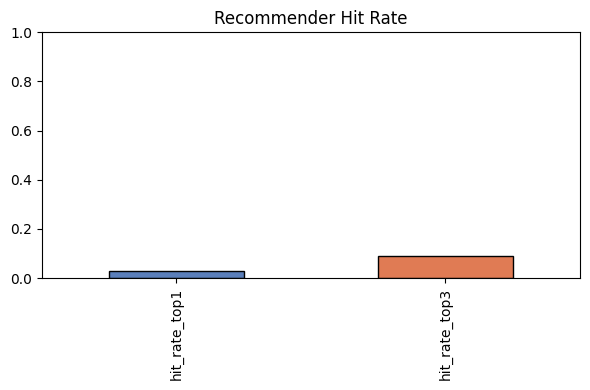

In [37]:
FIGURES_DIR = Path("../../Figures/Recommender_Outputs")

fig,ax = plt.subplots(figsize=(6,4))

pd.Series(results).plot(
    kind="bar",
    color=["#5b7fba","#e07b54"],
    edgecolor="black",
    ax=ax
)

ax.set_ylim(0,1)
ax.set_title("Recommender Hit Rate")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR/"recommender_hit_rates_rtr.png",
    dpi=300
)

plt.show()

## 7. Warm-Start Demo

In [38]:
sample = df_train.iloc[0]

recs = rec.recommend(
    category=sample["category"],
    user_id=sample["user_id"]
)

print("Actual size:", sample["size"])
recs.head(10)

Actual size: 14


,size,score,weighted_prob,popularity,n_neighbours
0,45,0.6085,0.8670,0.0079,20
1,12,0.5682,0.7758,0.1254,20
2,14,0.5544,0.7682,0.0832,20
3,35,0.5290,0.7550,0.0025,20
4,19,0.4800,0.6857,0.0002,6
5,26,0.4748,0.6767,0.0052,20
6,3,0.4568,0.6523,0.0010,20
7,6,0.4465,0.6379,0.0001,4
8,17,0.4039,0.5762,0.0028,20
9,5,0.3770,0.5376,0.0032,20


## 8. Cold-Start Demo (New Customer — No Purchase History)

In [39]:
popular_category = df_train["category"].value_counts().index[0]

cold_recs = rec.recommend(
    category=popular_category,
    user_id=df_train["user_id"].iloc[0]  # proxy
)

cold_recs.head(10)

,size,score,weighted_prob,popularity,n_neighbours
0,23,0.5411,0.7729,0.0006,20
1,14,0.4946,0.6937,0.0450,20
2,19,0.4595,0.6562,0.0007,20
3,8,0.4544,0.5925,0.1981,20
4,35,0.4363,0.6215,0.0063,20
5,16,0.4177,0.5696,0.0949,20
6,2,0.4171,0.5944,0.0048,20
7,40,0.4105,0.5862,0.0006,20
8,39,0.3893,0.5545,0.0055,20
9,26,0.3881,0.5533,0.0039,20


## 9. Cross-Retailer Generalisation (ModCloth → RentTheRunway)

In [40]:
df_modcloth = load_data("modcloth")

rec_cross = SizeRecommender(k=20).fit(df_modcloth)

cross_results={
"hit_rate_top1":evaluate_recommender(rec_cross,df_test,1),
"hit_rate_top3":evaluate_recommender(rec_cross,df_test,3)
}

pd.Series(cross_results)

Matrix shape: (47958, 90)


hit_rate_top1    0.104821
hit_rate_top3    0.321820
dtype: float64

### Within-retailer vs Cross-retailer comparison

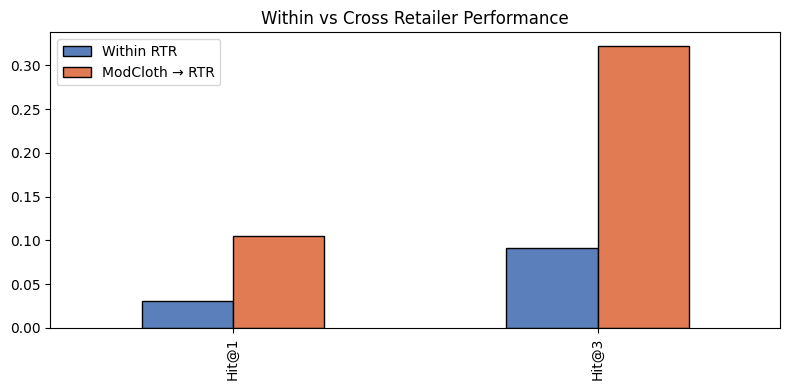

In [41]:
compare = pd.DataFrame({
"Within RTR":[
results["hit_rate_top1"],
results["hit_rate_top3"]
],
"ModCloth → RTR":[
cross_results["hit_rate_top1"],
cross_results["hit_rate_top3"]
]
},
index=["Hit@1","Hit@3"])

compare.plot(
kind="bar",
figsize=(8,4),
color=["#5b7fba","#e07b54"],
edgecolor="black"
)

plt.title("Within vs Cross Retailer Performance")

plt.tight_layout()

plt.savefig(
FIGURES_DIR/"cross_retailer_comparison.png",
dpi=300
)

plt.show()